In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random 
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
rng = np.random.default_rng(42)


print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [14]:
# Directory path containing banknote folders (e.g., '10_Dollar', '20_Dollar', '100_Dollar' or 'GENUINE', 'COUNTERFEIT')
# DATA_ROOT = 'dataset/Ethiopian note currency'
DATA_ROOT = os.path.join("dataset", "Ethiopian_Currency")
CLASSES = ["5back", "5front", "10back","10front","50back","50front",
           "100back","100front","200back","200front","background"]
IMG_SIZE = 100
BATCH_SIZE = 32
EPOCHS = 25

if os.path.exists(DATA_ROOT):
    print(f"Data root verified at: {DATA_ROOT}")
else:
    print(f"Warning: Directory '{DATA_ROOT}' not found. Please verify folder location.")

Data root verified at: dataset\Ethiopian_Currency


In [15]:
# Task 1a: Count image samples per class across splits
print("\n--- Image Counts per Split & Class ---")

for split in ["train", "test"]:
    print(f"--- {split} ---")
    for cls in CLASSES:
        path = os.path.join(DATA_ROOT, split, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"  {cls}: {count} images")



--- Image Counts per Split & Class ---
--- train ---
  5back: 148 images
  5front: 148 images
  10back: 148 images
  10front: 148 images
  50back: 148 images
  50front: 148 images
  100back: 148 images
  100front: 148 images
  200back: 148 images
  200front: 148 images
  background: 64 images
--- test ---
  5back: 36 images
  5front: 36 images
  10back: 36 images
  10front: 36 images
  50back: 36 images
  50front: 36 images
  100back: 36 images
  100front: 36 images
  200back: 36 images
  200front: 36 images
  background: 15 images


In [16]:
print("\n--- Sample Image Details ---")
for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, "train", cls)
    if os.path.exists(cls_dir):
        sample_files = os.listdir(cls_dir)[:3]
        for f in sample_files:
            path = os.path.join(cls_dir, f)
            with Image.open(path) as img:
                print(f"Class: {cls:<5} | Dimensions: {str(img.size):<12} | Mode: {img.mode}")


--- Sample Image Details ---
Class: 5back | Dimensions: (256, 256)   | Mode: RGB
Class: 5back | Dimensions: (256, 256)   | Mode: RGB
Class: 5back | Dimensions: (256, 256)   | Mode: RGB
Class: 5front | Dimensions: (256, 256)   | Mode: RGB
Class: 5front | Dimensions: (256, 256)   | Mode: RGB
Class: 5front | Dimensions: (256, 256)   | Mode: RGB
Class: 10back | Dimensions: (256, 256)   | Mode: RGB
Class: 10back | Dimensions: (256, 256)   | Mode: RGB
Class: 10back | Dimensions: (256, 256)   | Mode: RGB
Class: 10front | Dimensions: (256, 256)   | Mode: RGB
Class: 10front | Dimensions: (256, 256)   | Mode: RGB
Class: 10front | Dimensions: (256, 256)   | Mode: RGB
Class: 50back | Dimensions: (256, 256)   | Mode: RGB
Class: 50back | Dimensions: (256, 256)   | Mode: RGB
Class: 50back | Dimensions: (256, 256)   | Mode: RGB
Class: 50front | Dimensions: (256, 256)   | Mode: RGB
Class: 50front | Dimensions: (256, 256)   | Mode: RGB
Class: 50front | Dimensions: (256, 256)   | Mode: RGB
Class: 100bac

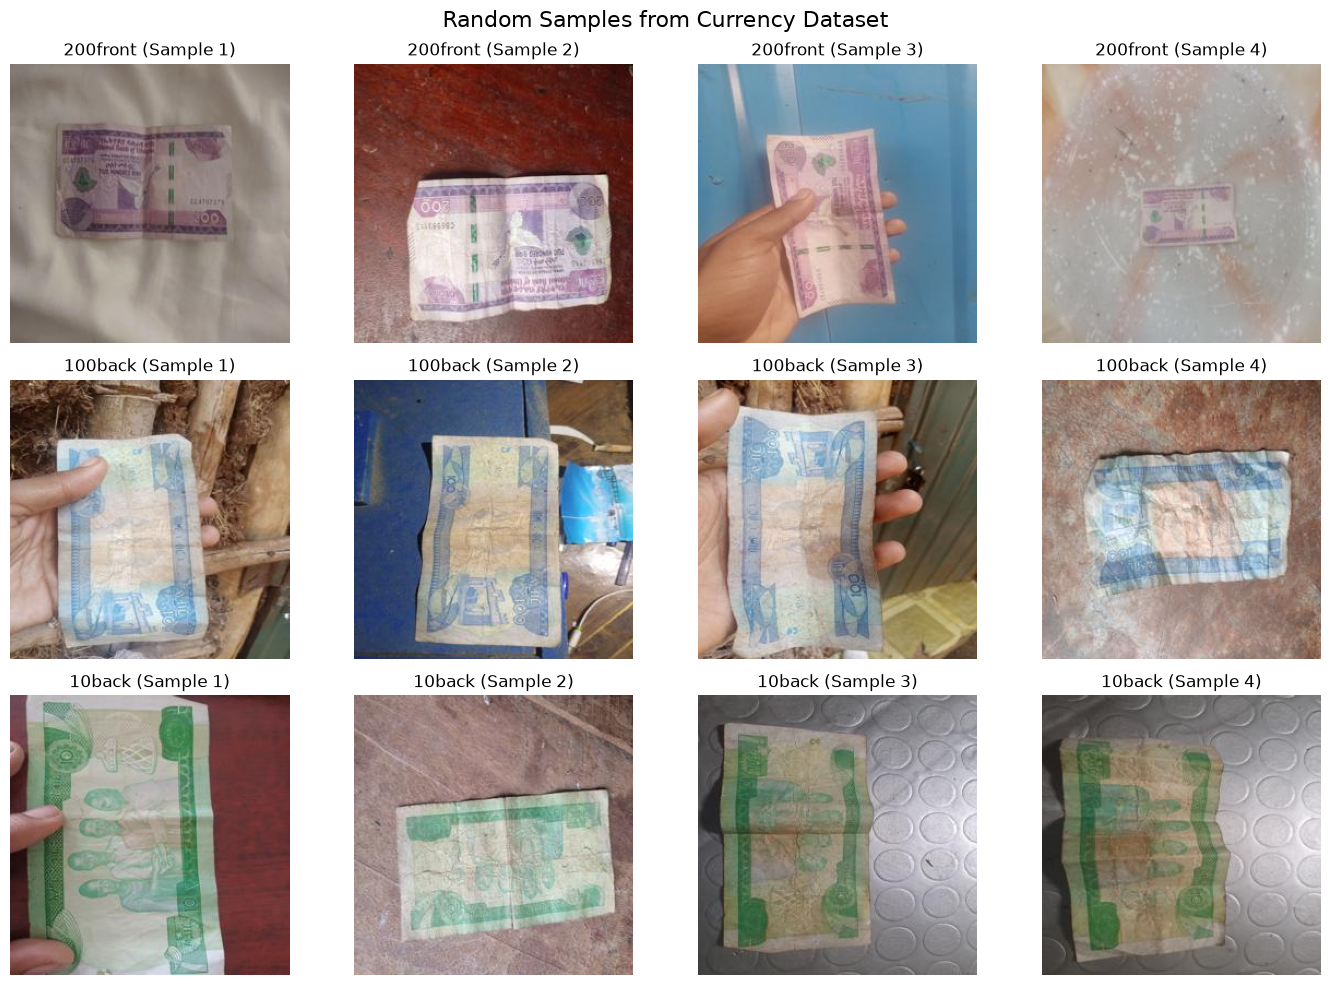

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

# 1. Randomly select 3 classes from your list for the 3 rows
selected_classes = random.sample(CLASSES, 3)

for row_idx, cls in enumerate(selected_classes):
    cls_dir = os.path.join(DATA_ROOT, "train", cls)
    
    # Get all images in the folder, filtering out hidden files
    all_files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    # 2. Randomly select 4 images for the 4 columns
    # We use min() just in case a folder has fewer than 4 images
    num_to_display = min(4, len(all_files))
    selected_files = random.sample(all_files, num_to_display)
    
    for col_idx, file_name in enumerate(selected_files):
        img_path = os.path.join(cls_dir, file_name)
        
        # Open and display
        with Image.open(img_path) as img:
            axes[row_idx, col_idx].imshow(img)
            # Shows the class name and the image number in that row
            axes[row_idx, col_idx].set_title(f"{cls} (Sample {col_idx + 1})")
            axes[row_idx, col_idx].axis("off")

    # Clean up: If a folder had < 4 images, hide the remaining empty plots in that row
    for empty_col in range(num_to_display, 4):
        axes[row_idx, empty_col].axis("off")

plt.suptitle("Random Samples from Currency Dataset", fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
all_paths, all_labels = [], []

# TODO: fill this in with a loop over [("NORMAL", 0), ("PNEUMONIA", 1)]
classes_label = [("5back",0), ("5front",0), ("10back",1),("10front",1),
                 ("50back",2),("50front",2),
                ("100back",3),("100front",3),
                ("200back",4),("200front",4)]

for cls_name, label in classes_label:
    cls_dir = os.path.join(DATA_ROOT, "train", cls_name)
    if os.path.exists(cls_dir):
        for fname in os.listdir(cls_dir):
            all_paths.append(os.path.join(cls_dir, fname))
            all_labels.append(label)
            
print(f"Total train-folder images collected: {len(all_paths)} images")



Total train-folder images collected: 1480 images


In [19]:
# TODO 2b: Use sklearn's train_test_split to create an 85/15 train/val split,
# STRATIFIED by class so the ratio is preserved in both.
# Hint: train_test_split(X, y, test_size=..., stratify=..., random_state=42)


train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.15,
    stratify=all_labels,
    random_state=42
)



if train_paths is not None:
    print(f"Train: {len(train_paths)} images | Val: {len(val_paths)} images")

    print(f"Train ratio: {train_labels.count(1)/len(train_labels):.3f}")
    print(f"Val ratio:   {val_labels.count(1)/len(val_labels):.3f}\n")


Train: 1258 images | Val: 222 images
Train ratio: 0.200
Val ratio:   0.198



In [20]:

def load_and_preprocess(path, augment=False):
    """
    TODO 3a: Load the image at `path`, convert to grayscale, resize to (IMG_SIZE, IMG_SIZE),
    and scale pixel values to [0, 1] as a float32 numpy array.

    TODO 3b: If augment=True, apply (in any order):
      - a 50% chance random horizontal flip (np.fliplr)
      - a random rotation between -15 and +15 degrees
        (hint: convert back to a PIL Image, use .rotate(angle), then back to a normalized array)
      - a random brightness scaling factor between 0.9x and 1.1x (remember to np.clip to [0,1] after)

    Return the final array with an added channel dimension: shape (IMG_SIZE, IMG_SIZE, 1).
    """
    with Image.open(path) as img:
        img = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        arr = np.array(img, dtype=np.float32) / 255.0

    if augment:
        if rng.random() < 0.5:
            arr = np.fliplr(arr)
        
        angle = rng.uniform(-15, 15)
        temp_img = Image.fromarray((arr * 255).astype(np.uint8))
        rotated = temp_img.rotate(angle)
        arr = np.array(rotated, dtype=np.float32) / 255.0
        
        factor = rng.uniform(0.9, 1.1)
        arr = np.clip(arr * factor, 0.0, 1.0)

    return arr
    


def generator_fn(paths, labels, augment):
    indices = np.arange(len(paths))
    if augment:
        rng.shuffle(indices)
    for idx in indices:
        img_arr = load_and_preprocess(paths[idx], augment=augment)
        yield img_arr, labels[idx]


def build_dataset(paths, labels, augment):
    """
    TODO 3c: Wrap load_and_preprocess in a tf.data.Dataset using Dataset.from_generator,
    with output_signature matching (IMG_SIZE, IMG_SIZE, 1) float32 images and scalar int32 labels.
    Shuffle only when augment=True. Batch with BATCH_SIZE and .prefetch(tf.data.AUTOTUNE).
    """
    output_signature = (
    tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    dataset = tf.data.Dataset.from_generator(
        lambda: generator_fn(paths, labels, augment),
        output_signature=output_signature
    )
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# Once the two functions above are implemented, uncomment these lines:
train_ds = build_dataset(train_paths, train_labels, augment=True)
val_ds   = build_dataset(val_paths,   val_labels,   augment=False)
for imgs, lbls in train_ds.take(1):
    print("Batch shape:", imgs.shape, "value range:", float(tf.reduce_min(imgs)), "-", float(tf.reduce_max(imgs)))



Batch shape: (32, 100, 100, 3) value range: 0.0 - 1.0


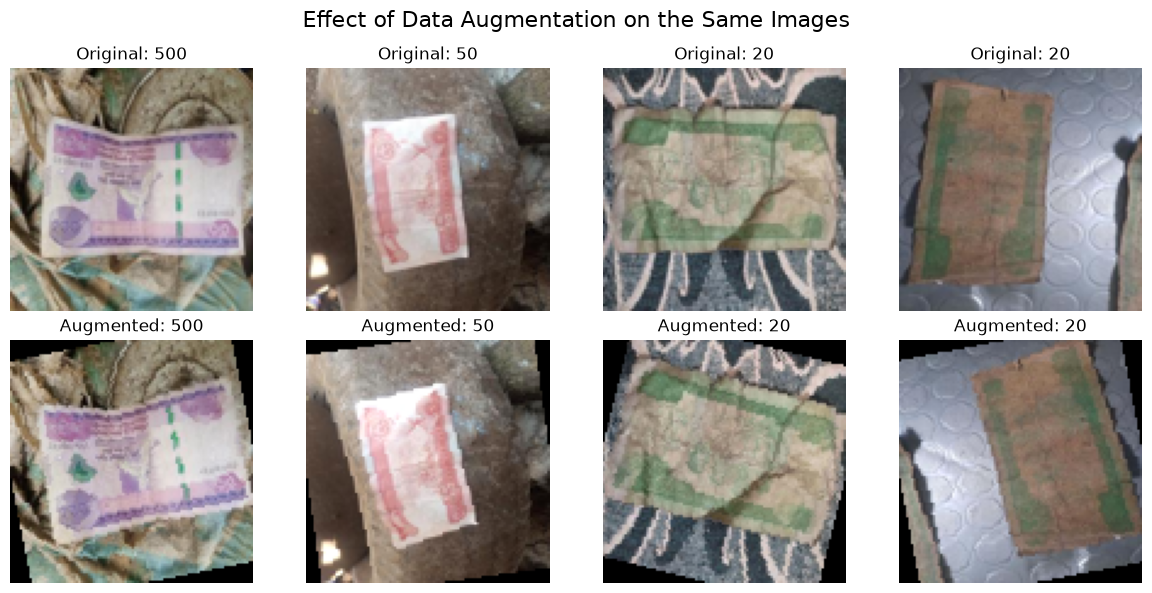

In [24]:
# TODO 3d: Visualize a few augmented training images next to their un-augmented val counterparts.
# This is a sanity check -- augmented images should look like plausible variations, not garbage.
# 1. Define your labels
class_names = ["10", "20", "50", "100", "500"]

# 2. Pick 4 specific images from your training paths to compare
sample_paths = train_paths[:4]
sample_labels = train_labels[:4]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    path = sample_paths[i]
    label_idx = sample_labels[i]
    label_name = class_names[label_idx]

    # --- TOP ROW: Original (No Augmentation) ---
    # We call the function manually with augment=False
    original_img = load_and_preprocess(path, augment=False)
    axes[0, i].imshow(original_img)
    axes[0, i].set_title(f"Original: {label_name}")
    axes[0, i].axis("off")

    # --- BOTTOM ROW: Augmented (Same Image) ---
    # We call the function manually with augment=True
    augmented_img = load_and_preprocess(path, augment=True)
    axes[1, i].imshow(augmented_img)
    axes[1, i].set_title(f"Augmented: {label_name}")
    axes[1, i].axis("off")

plt.suptitle("Effect of Data Augmentation on the Same Images", fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
# TODO 3e: Compute class weights from the ORIGINAL train label counts (from Task 1/2),
# BEFORE any augmentation. Use sklearn's compute_class_weight with class_weight="balanced".
# Store the result as a dict: {0: weight_for_NORMAL, 1: weight_for_PNEUMONIA}

classes= np.unique(train_labels)
weights= compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y= train_labels
)


class_weight_dict = dict(
    zip(
        classes,
        weights
    )
)

if class_weight_dict:
    print("Class weights", class_weight_dict)


Class weights {np.int64(0): np.float64(1.002390438247012), np.int64(1): np.float64(0.9984126984126984), np.int64(2): np.float64(0.9984126984126984), np.int64(3): np.float64(1.002390438247012), np.int64(4): np.float64(0.9984126984126984)}


In [26]:
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Dense Classification Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(classes_label), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Abi\Desktop\deep learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,733,066 (6.61 MB)

 Trainable params: 1,733,066 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Starting model training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Starting model training...
Epoch 1/25


c:\Users\Abi\Desktop\deep learning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


     40/Unknown 40s 808ms/step - accuracy: 0.2019 - loss: 1.8534

c:\Users\Abi\Desktop\deep learning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


40/40 ━━━━━━━━━━━━━━━━━━━━ 46s 958ms/step - accuracy: 0.2019 - loss: 1.8534 - val_accuracy: 0.2027 - val_loss: 1.6496
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 317ms/step - accuracy: 0.2822 - loss: 1.6174 - val_accuracy: 0.4459 - val_loss: 1.3720
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 335ms/step - accuracy: 0.4436 - loss: 1.3830 - val_accuracy: 0.4820 - val_loss: 1.3156
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 285ms/step - accuracy: 0.4841 - loss: 1.2847 - val_accuracy: 0.6622 - val_loss: 0.9158
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 291ms/step - accuracy: 0.6280 - loss: 0.9241 - val_accuracy: 0.7027 - val_loss: 0.7666
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 288ms/step - accuracy: 0.6916 - loss: 0.7856 - val_accuracy: 0.7477 - val_loss: 0.6309
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 318ms/step - accuracy: 0.7488 - loss: 0.6510 - val_accuracy: 0.7838 - val_loss: 0.5451
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 283ms/step - accuracy: 0.7846 - loss: 0.5811 - val_accuracy: 0.851

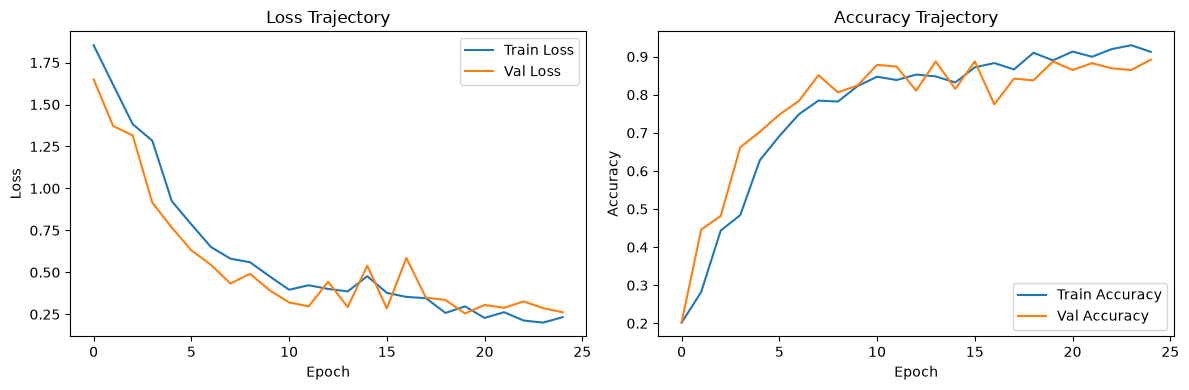

In [28]:
# 4. Plot Training & Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss Trajectory')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy Trajectory')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [29]:
# TODO 6a: Build a test dataset the same way as val_ds (NO augmentation -- this is your
# untouched, final-answer evaluation set). Gather test_paths/test_labels, then build_dataset(...).

test_paths, test_labels = [], []
# TODO: fill in like Task 2a but for the "test" split

for cls_name,label in classes_label:
    cls_dir= os.path.join(DATA_ROOT,'test',cls_name)
    if os.path.exists(cls_dir):
        for fname in os.listdir(cls_dir):
            test_paths.append(os.path.join(cls_dir,fname))
            test_labels.append(label)
            
test_ds= build_dataset(test_paths,test_labels,augment=False)


In [30]:
# 2. Detailed Classification Report
y_true = np.array(test_labels)

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred

# 1. Test Set Evaluation
# test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
# print(f"\nTest Loss:     {test_loss:.4f}")
# print(f"Test Accuracy: {test_acc:.4f}\n")

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 302ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0,
       3, 0, 0, 0, 3, 3, 1, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 4, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 1, 3, 3, 3,
       0, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3,
       3, 3, 3, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 0,
       0, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

--- Classification Report ---
              precision    recall  f1-score   support

           5       0.78      0.86      0.82        72
          10       0.91      0.97      0.94        72
          50       0.91      0.93      0.92        72
         100       0.92      0.79      0.85        72
         200       0.97      0.92      0.94        72

    accuracy                           0.89       360
   macro avg       0.90      0.89      0.89       360
weighted avg       0.90      0.89      0.89       360



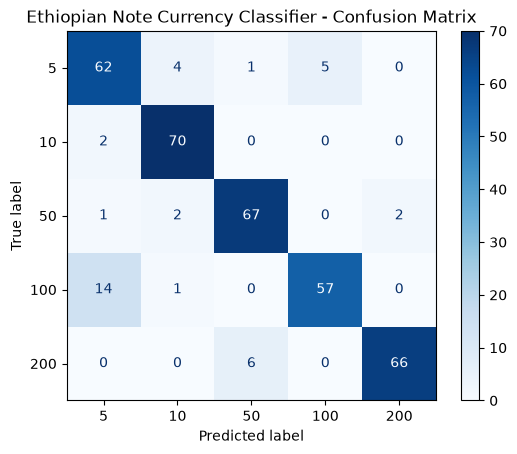

In [31]:
print("--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['5','10','50','100','200']))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['5','10','50','100','200'])
disp.plot(cmap=plt.cm.Blues)

plt.title("Ethiopian Note Currency Classifier - Confusion Matrix")
plt.show()

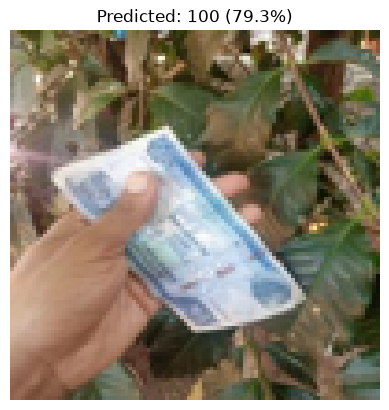

gTTSError: Failed to connect. Probable cause: Unknown

In [ ]:
from gtts import gTTS
from IPython.display import Audio, display

def speak_currency_amharic(label_idx):
    """
    Takes a label index and plays the corresponding Amharic audio.
    """
    # Mapping indices to Amharic Text
    amharic_labels = {
        0: "አምስት ብር",      # 5 Birr
        1: "አስር ብር",        # 10 Birr
        2: "ሃምሳ ብር",        # 50 Birr
        3: "መቶ ብር",         # 100 Birr
        4: "ሁለት መቶ ብር"      # 200 Birr
    }
    
    text = amharic_labels.get(label_idx, "የማይታወቅ ብር") # Default to "Unknown"
    
    # Generate Speech
    tts = gTTS(text=text, lang='am')
    filename = "result.mp3"
    tts.save(filename)
    
    # Play the audio in the notebook
    print(f"Amharic Audio: {text}")
    display(Audio(filename, autoplay=True))

def predict_and_speak(image_path):
    """
    Full pipeline: Preprocess -> Predict -> Display -> Speak
    """
    # 1. Preprocess the image
    img_arr = load_and_preprocess(image_path, augment=False)
    
    # 2. Make Prediction (add batch dimension)
    img_batch = np.expand_dims(img_arr, axis=0)
    preds = model.predict(img_batch, verbose=0)
    predicted_idx = np.argmax(preds)
    confidence = np.max(preds) * 100
    
    # 3. Display the image
    plt.imshow(img_arr)
    plt.title(f"Predicted: {class_names[predicted_idx]} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()
    
    # 4. Speak the result in Amharic
    speak_currency_amharic(predicted_idx)

# --- TEST IT ON A RANDOM IMAGE FROM TEST SET ---
random_test_path = random.choice(test_paths)
predict_and_speak(random_test_path)